In [1]:
import importlib
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# --
# import _004_PRC_interaction_chains
# importlib.reload(_004_PRC_interaction_chains)
# from _004_PRC_interaction_chains import generate_transition_matrix_from_categorized
# --
import _010_PRC_extended_interaction_chains
importlib.reload(_010_PRC_extended_interaction_chains)
from _010_PRC_extended_interaction_chains import generate_transition_matrix, parallel_memory_categorization
# --
import _007_EXP_model_validation
importlib.reload(_007_EXP_model_validation)
from _007_EXP_model_validation import get_mm_empirical_distribution, get_md_empiricial_distribution, plot_side_by_side_histograms, mm_permiability_from_path, md_permiability_from_path, get_mm_stationary_distribution, mm_permiability_from_path_fast
# --

In [2]:
lengths = [10, 30, 50, 100, 200, 300]
amounts = [10, 100, 1000, 10000]

In [8]:
# generate memory interaction transition matrices from less data

with open("data/categorized/mem-with-0.1init/interactionsmem-window32-p0.1-150-180-100ns.pickle", "rb") as f:
        orig_categorized = pickle.load(f)

for series_len in lengths:
    for n_molecules in amounts:
        print(f"processing series_len: {series_len}, n_molecules: {n_molecules}")
        # randomly choose n_molecules indices from 12500
        indices = np.random.choice(12500, n_molecules, replace=False)
        categorized_trajectories = orig_categorized[indices, -series_len:]
        
        tm, states = generate_transition_matrix(categorized_trajectories,
                                        fg_types=['Nup2', 'Nsp1', 'Nup100', 'Nup116', 'Nup159', 'Nup49', 'Nup57', 'Nup145', 'Nup1', 'Nup60'],
                                        n_chains_per_fg=[16, 48, 16, 16, 16, 32, 32, 16, 8, 16],
                                        init_1 = True,
                                        symmetrize = True,
                                        add_to_diag = 0.9)
        
        with open(f"data/transition_matrices/less-data-mem2/interactions-{int(series_len/10)}us-{n_molecules}n.pickle", "wb") as f:
            pickle.dump((tm, states), f)

processing series_len: 10, n_molecules: 10
processing series_len: 10, n_molecules: 100
processing series_len: 10, n_molecules: 1000
processing series_len: 10, n_molecules: 10000
processing series_len: 30, n_molecules: 10
processing series_len: 30, n_molecules: 100
processing series_len: 30, n_molecules: 1000
processing series_len: 30, n_molecules: 10000
processing series_len: 50, n_molecules: 10
processing series_len: 50, n_molecules: 100
processing series_len: 50, n_molecules: 1000
processing series_len: 50, n_molecules: 10000
processing series_len: 100, n_molecules: 10
processing series_len: 100, n_molecules: 100
processing series_len: 100, n_molecules: 1000
processing series_len: 100, n_molecules: 10000
processing series_len: 200, n_molecules: 10
processing series_len: 200, n_molecules: 100
processing series_len: 200, n_molecules: 1000
processing series_len: 200, n_molecules: 10000
processing series_len: 300, n_molecules: 10
processing series_len: 300, n_molecules: 100
processing se

In [4]:


from scipy.stats import entropy, kstest
from scipy.spatial.distance import jensenshannon

def kl_divergence(hist1, hist2, eps=1e-10):
    """Calculate KL divergence between two histograms"""
    # Add small epsilon to avoid division by zero
    p = hist1 + eps
    q = hist2 + eps
    
    # Normalize if not already normalized
    p = p / np.sum(p)
    q = q / np.sum(q)
    
    return entropy(p, q)

def ks_test(hist1, hist2):
    res = kstest(hist1, hist2)
    return res.statistic

In [ ]:
# generate md empirical dists
for i, series_len in enumerate(lengths):
    for j, n_molecules in enumerate(amounts):
        empirical_dist = get_md_empiricial_distribution(traj_path='data/categorized/interactions-150-180-100ns.pickle',
                                         n_series=n_molecules,
                                         series_len=series_len)
        with open(f"data/empirical_dists/md-interactions-{int(series_len/10)}us-{n_molecules}n.pickle", "wb") as f:
            pickle.dump(empirical_dist, f)

1.1789591420693253 0.31208228341472555 0.0481864405420208 0.021768627814729553 
1.0572295686241637 0.14059235631708608 0.028916747884706186 0.014857832364845733 
0.8429976976412175 0.1436176500910355 0.03157771573678254 0.011479591014242906 
0.9088433880917017 0.13670223622759795 0.01476204441512817 0.0066966773535128785 
0.5744102538640656 0.09166405036884098 0.007221815513532604 0.002075432059738927 
0.4054412362534392 0.06522452337541676 0.005177588956021927 0.0 


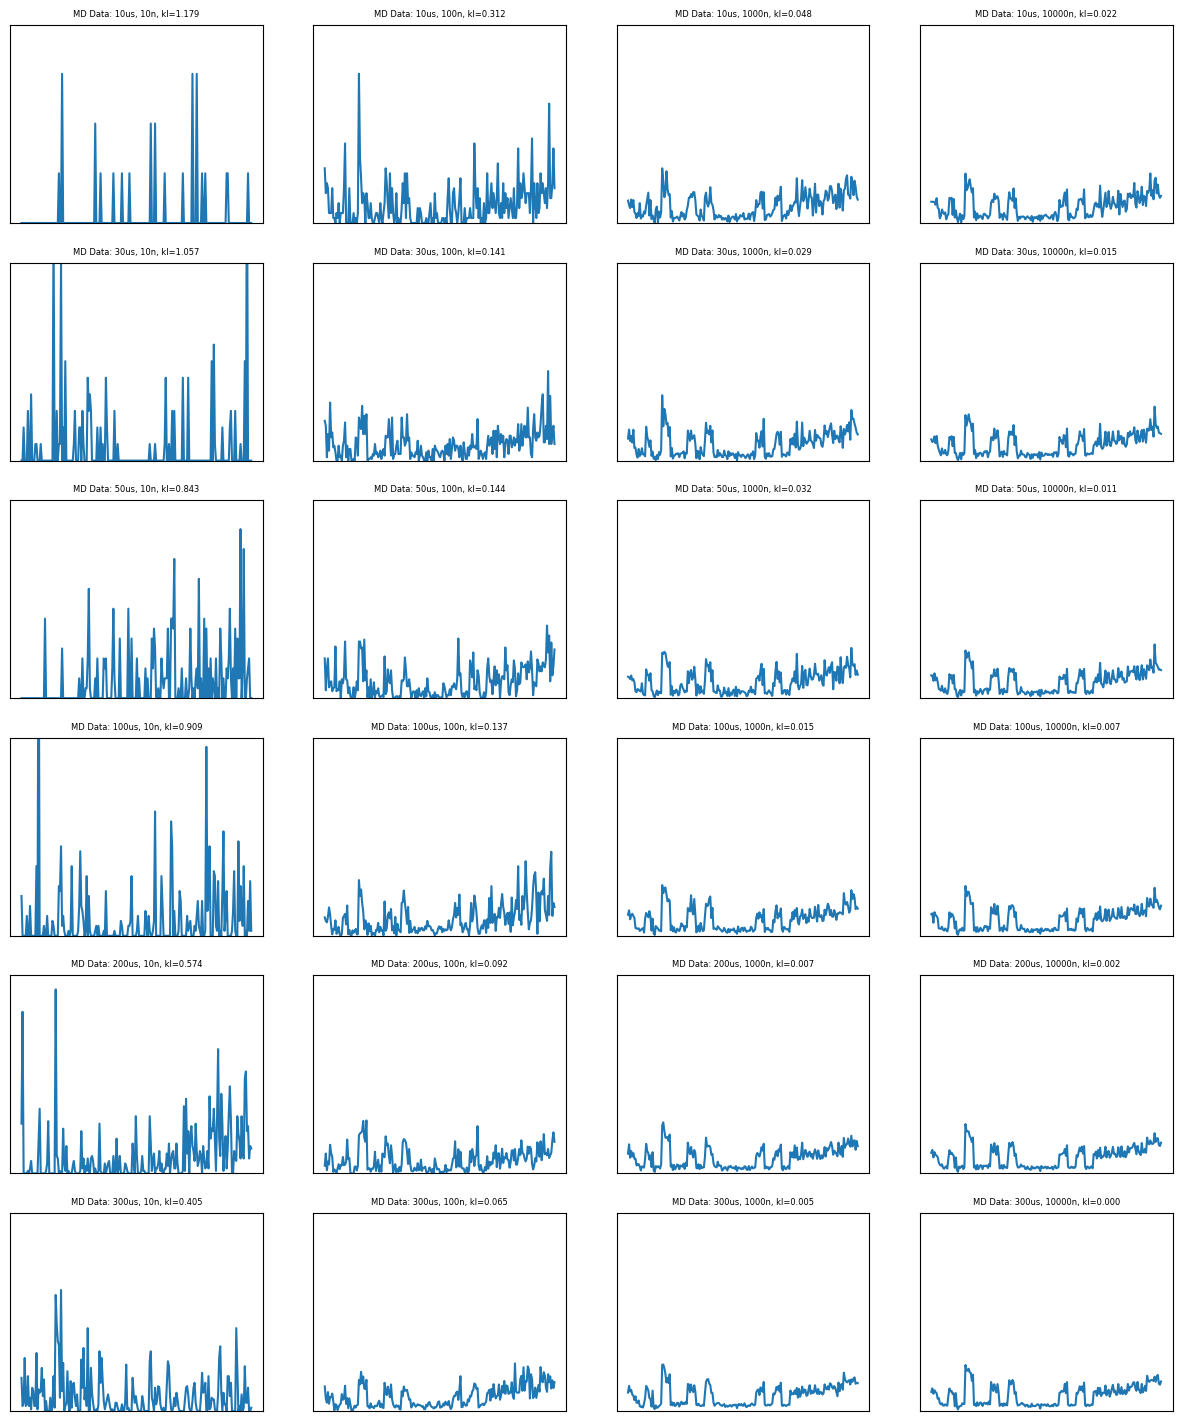

In [ ]:
with open(f"data/empirical_dists/md-interactions-{int(300/10)}us-{10000}n.pickle", "rb") as f:
    best_md_dist = pickle.load(f)

# visualize md empirical dists
plt.figure(figsize=(15, 18))
for i, series_len in enumerate(lengths):
    for j, n_molecules in enumerate(amounts):
        plt.subplot(6, 4, i*4 + j + 1)
        
        with open(f"data/empirical_dists/md-interactions-{int(series_len/10)}us-{n_molecules}n.pickle", "rb") as f:
            a = pickle.load(f)
        
        kld = kl_divergence(a, best_md_dist)
        print(kld, end=" ")
        a = a[1:-1]
        
        sns.lineplot(x=range(216), y=a)
        # remove x and y ticks
        plt.xticks([])
        plt.yticks([])
        plt.ylim(0, 0.04)
        plt.title(f"MD Data: {series_len}us, {n_molecules}n, kl={kld:.3f}", fontsize=6)
    print()
plt.show()


In [ ]:
# generate mm empirical dists
for i, series_len in enumerate(lengths):
    for j, n_molecules in enumerate(amounts):
        print(f"processing series_len: {series_len}, n_molecules: {n_molecules}")        
        a = get_md_empiricial_distribution(traj_path='data/categorized/interactions-150-180-100ns.pickle',
                                         n_series=n_molecules,
                                         series_len=series_len)
        def count_values(series):
            return np.bincount(series, minlength=218)# This gives counts for values 0 to 217

        a = np.append(a, np.zeros(218))
        a = a / np.sum(a)
        
        mm_empirical_dist = get_mm_empirical_distribution(tm_path=f"data/transition_matrices/less-data-mem/interactions-{int(series_len/10)}us-{n_molecules}n.pickle",
                                          n_series=10000,
                                          series_len=500,
                                          mem=True,
                                          init_dist=a)
        
        with open(f"data/empirical_dists/mm-interactions-{int(series_len/10)}us-{n_molecules}n.pickle", "wb") as f:
            pickle.dump(mm_empirical_dist, f)
        

processing series_len: 10, n_molecules: 10
processing series_len: 10, n_molecules: 100
processing series_len: 10, n_molecules: 1000
processing series_len: 10, n_molecules: 10000
processing series_len: 30, n_molecules: 10
processing series_len: 30, n_molecules: 100
processing series_len: 30, n_molecules: 1000
processing series_len: 30, n_molecules: 10000
processing series_len: 50, n_molecules: 10
processing series_len: 50, n_molecules: 100
processing series_len: 50, n_molecules: 1000
processing series_len: 50, n_molecules: 10000
processing series_len: 100, n_molecules: 10
processing series_len: 100, n_molecules: 100
processing series_len: 100, n_molecules: 1000
processing series_len: 100, n_molecules: 10000
processing series_len: 200, n_molecules: 10
processing series_len: 200, n_molecules: 100
processing series_len: 200, n_molecules: 1000
processing series_len: 200, n_molecules: 10000
processing series_len: 300, n_molecules: 10
processing series_len: 300, n_molecules: 100
processing se

In [ ]:
# generate mm stationary dists
for i, series_len in enumerate(lengths):
    for j, n_molecules in enumerate(amounts):
        # print(f"processing series_len: {series_len}, n_molecules: {n_molecules}")                
        mm_stationary_dist = get_mm_stationary_distribution(tm_path=f"data/transition_matrices/less-data-mem/interactions-{int(series_len/10)}us-{n_molecules}n.pickle",
                                          mem=True)
        with open(f"data/stationary_dists/mm-interactions-{int(series_len/10)}us-{n_molecules}n.pickle", "wb") as f:
            pickle.dump(mm_stationary_dist, f)

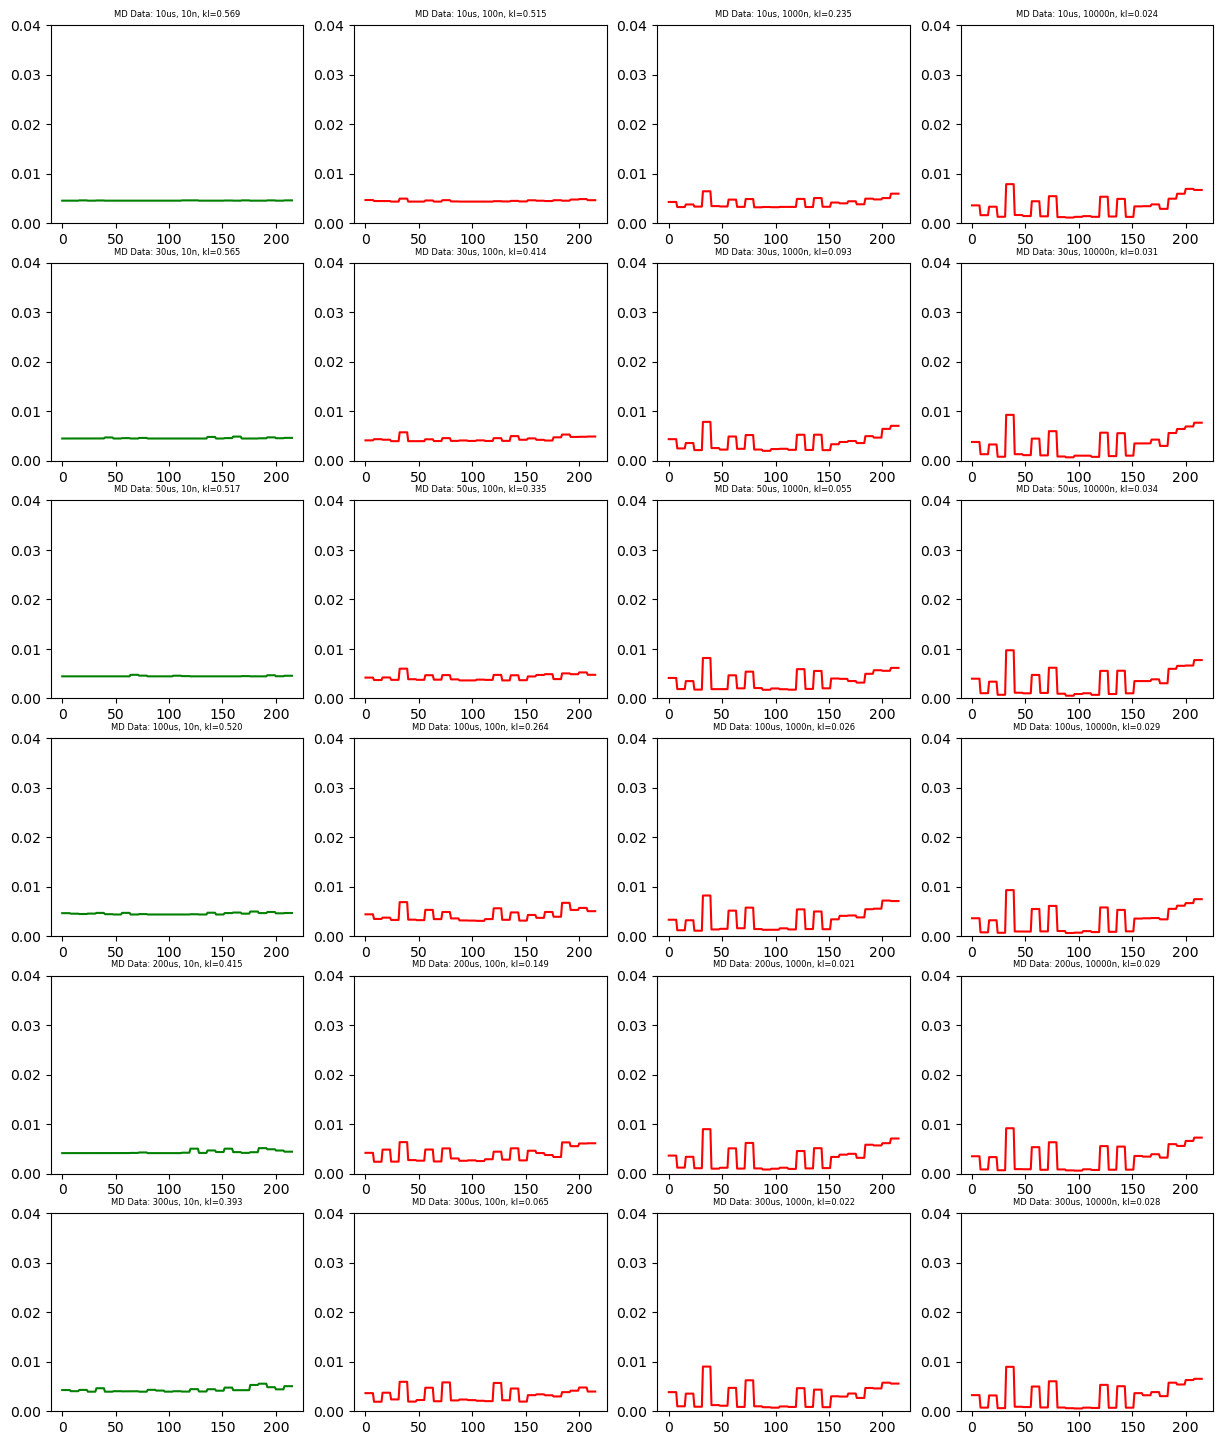

In [ ]:
with open(f"data/empirical_dists/md-interactions-{int(300/10)}us-{10000}n.pickle", "rb") as f:
    best_md_dist = pickle.load(f)

# visualize mm empirical dists
plt.figure(figsize=(15, 18))
for i, series_len in enumerate(lengths):
    for j, n_molecules in enumerate(amounts):
        plt.subplot(6, 4, i*4 + j+1)
        
        with open(f"data/stationary_dists/mm-interactions-{int(series_len/10)}us-{n_molecules}n.pickle", "rb") as f:
            mm_empirical_dist = pickle.load(f)
        mm_kld = kl_divergence(mm_empirical_dist, best_md_dist)
        mm_empirical_dist = mm_empirical_dist[1:-1]
        
        
        with open(f"data/empirical_dists/md-interactions-{int(series_len/10)}us-{n_molecules}n.pickle", "rb") as f:
            md_empirical_dist = pickle.load(f)
        md_kld = kl_divergence(md_empirical_dist, best_md_dist)
        
        if mm_kld > md_kld:
            sns.lineplot(x=range(216), y=mm_empirical_dist, color='red')
        else:
            sns.lineplot(x=range(216), y=mm_empirical_dist, color='green')
        plt.ylim(0, 0.04)
        plt.title(f"MD Data: {series_len}us, {n_molecules}n, kl={mm_kld:.3f}", fontsize=6)
plt.show()

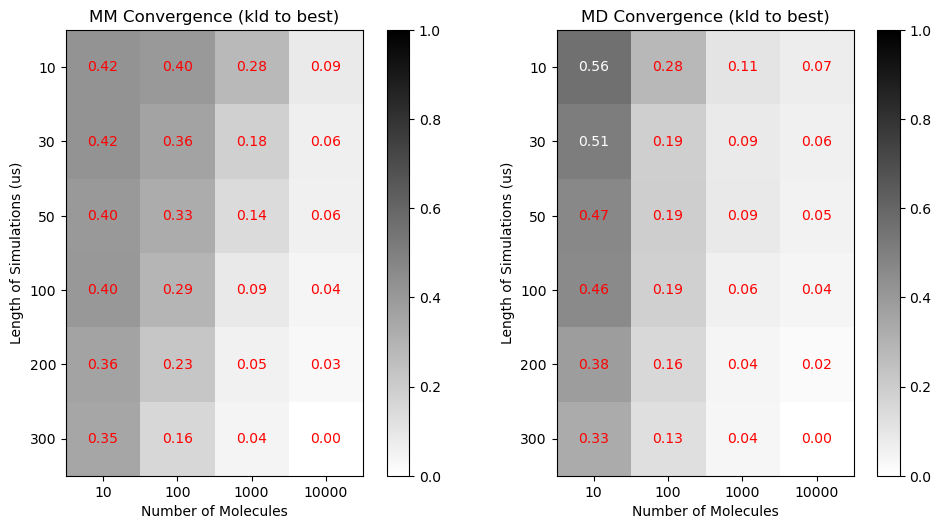

In [ ]:
# before we only checked similiarity to the best md empirical dist
# no we check how fast the model converges
# so for mm and md, we will compare each distribution to the best one for that specific model
# this will be done using the KL divergence.
# this will result in 2 heatmaps, and hopefully the markov model converges first.
with open(f"data/stationary_dists/mm-interactions-{int(300/10)}us-{10000}n.pickle", "rb") as f:
    best_mm_dist = pickle.load(f)
with open(f"data/empirical_dists/md-interactions-{int(300/10)}us-{10000}n.pickle", "rb") as f:
    best_md_dist = pickle.load(f)

mm_klds = np.zeros((len(lengths), len(amounts)))
md_klds = np.zeros((len(lengths), len(amounts)))


for i, series_len in enumerate(lengths):
    for j, n_molecules in enumerate(amounts):
        
        with open(f"data/stationary_dists/mm-interactions-{int(series_len/10)}us-{n_molecules}n.pickle", "rb") as f:
            mm_empirical_dist = pickle.load(f)
        mm_kld = jensenshannon(mm_empirical_dist, best_mm_dist)
        
        with open(f"data/empirical_dists/md-interactions-{int(series_len/10)}us-{n_molecules}n.pickle", "rb") as f:
            md_empirical_dist = pickle.load(f)
        md_kld = jensenshannon(md_empirical_dist, best_md_dist)
        
        mm_klds[i, j] = mm_kld
        md_klds[i, j] = md_kld
plt.figure(figsize=(10, 10))

# First subplot - MM
plt.subplot(2, 2, 1)
plt.imshow(mm_klds, cmap='binary', interpolation='nearest', vmin=0, vmax=1)
plt.xlabel('Number of Molecules')
plt.ylabel('Length of Simulations (us)')
# set the ticks
plt.xticks(np.arange(len(amounts)), amounts)
plt.yticks(np.arange(len(lengths)), lengths)

# Add text annotations in the first heatmap
for i in range(len(lengths)):
    for j in range(len(amounts)):
        plt.text(j, i, f"{mm_klds[i, j]:.2f}", 
                 ha="center", va="center", 
                 color="red" if mm_klds[i, j] < 0.5 else "white")

plt.title('MM Convergence (kld to best)')
plt.colorbar()

# Second subplot - MD
plt.subplot(2, 2, 2)
plt.imshow(md_klds, cmap='binary', interpolation='nearest', vmin=0, vmax=1)
plt.xlabel('Number of Molecules')
plt.ylabel('Length of Simulations (us)')
# set the ticks
plt.xticks(np.arange(len(amounts)), amounts)
plt.yticks(np.arange(len(lengths)), lengths)

# Add text annotations in the second heatmap
for i in range(md_klds.shape[0]):
    for j in range(md_klds.shape[1]):
        plt.text(j, i, f"{md_klds[i, j]:.2f}", 
                 ha="center", va="center", 
                 color="red" if md_klds[i, j] < 0.5 else "white")

plt.title('MD Convergence (kld to best)')
plt.colorbar()
plt.tight_layout()
plt.show()

In [6]:
n_layers = 0
bottom_states = [0]
top_states = [217]
for i in range(0, n_layers):
    bottom_states += list(range(i*8 + 1, (i+1)*8 + 1))
    top_states += list(range(217 - (1+i)*8, 217 - (i)*8))


In [9]:
# generate mm permiabilities fast
mm_perms = np.zeros((len(lengths), len(amounts)))

for i, series_len in enumerate(lengths):
    for j, n_molecules in enumerate(amounts):
        print(f"processing series_len: {series_len}, n_molecules: {n_molecules}")
        with open(f"data/empirical_dists/md-interactions-{int(series_len/10)}us-{n_molecules}n.pickle", "rb") as f:
            md_empirical_dist = pickle.load(f)
        init_dist = np.append(md_empirical_dist, np.zeros(218))
        init_dist = init_dist / np.sum(init_dist)
        
        mm_perm = mm_permiability_from_path_fast(matrix_path=f"data/transition_matrices/less-data-mem2/interactions-{int(series_len/10)}us-{n_molecules}n.pickle",
                                            mem=True,
                                            bottom_states=np.concatenate([np.array(bottom_states), np.array(bottom_states) + 218]).tolist(),
                                            top_states=np.concatenate([np.array(top_states), np.array(top_states) + 218]).tolist(),
                                            )
        
        mm_perms[i, j] = mm_perm
with open(f"data/permiabilities/mm-permiabilities-fast.pickle", "wb") as f:
    pickle.dump(mm_perms, f)

processing series_len: 10, n_molecules: 10
processing series_len: 10, n_molecules: 100
processing series_len: 10, n_molecules: 1000
processing series_len: 10, n_molecules: 10000
processing series_len: 30, n_molecules: 10
processing series_len: 30, n_molecules: 100
processing series_len: 30, n_molecules: 1000
processing series_len: 30, n_molecules: 10000
processing series_len: 50, n_molecules: 10
processing series_len: 50, n_molecules: 100
processing series_len: 50, n_molecules: 1000
processing series_len: 50, n_molecules: 10000
processing series_len: 100, n_molecules: 10
processing series_len: 100, n_molecules: 100
processing series_len: 100, n_molecules: 1000
processing series_len: 100, n_molecules: 10000
processing series_len: 200, n_molecules: 10
processing series_len: 200, n_molecules: 100
processing series_len: 200, n_molecules: 1000
processing series_len: 200, n_molecules: 10000
processing series_len: 300, n_molecules: 10
processing series_len: 300, n_molecules: 100
processing se

In [31]:

# generate md permiabilities
md_perms = np.zeros((len(lengths), len(amounts)))
for i, series_len in enumerate(lengths):
    for j, n_molecules in enumerate(amounts):
        print(f"processing series_len: {series_len}, n_molecules: {n_molecules}")

        md_perm = md_permiability_from_path(traj_path='data/categorized/interactions-150-180-100ns.pickle',
                                            n_sims=n_molecules,
                                            sim_length=series_len,
                                            bottom_states=bottom_states,
                                            top_states=top_states)
        
        md_perms[i, j] = md_perm
        print(md_perm, end=" ")
with open(f"data/permiabilities/md-permiabilities.pickle", "wb") as f:
    pickle.dump(md_perms, f)

processing series_len: 10, n_molecules: 10
0.0 processing series_len: 10, n_molecules: 100
0.0 processing series_len: 10, n_molecules: 1000
49999.99999999999 processing series_len: 10, n_molecules: 10000
265000.0 processing series_len: 30, n_molecules: 10
0.0 processing series_len: 30, n_molecules: 100
833333.3333333333 processing series_len: 30, n_molecules: 1000
566666.6666666667 processing series_len: 30, n_molecules: 10000
605000.0 processing series_len: 50, n_molecules: 10
0.0 processing series_len: 50, n_molecules: 100
200000.00000000003 processing series_len: 50, n_molecules: 1000
1000000.0000000001 processing series_len: 50, n_molecules: 10000
687000.0 processing series_len: 100, n_molecules: 10
0.0 processing series_len: 100, n_molecules: 100
1950000.0000000002 processing series_len: 100, n_molecules: 1000
1005000.0000000001 processing series_len: 100, n_molecules: 10000
897000.0 processing series_len: 200, n_molecules: 10
0.0 processing series_len: 200, n_molecules: 100
10000

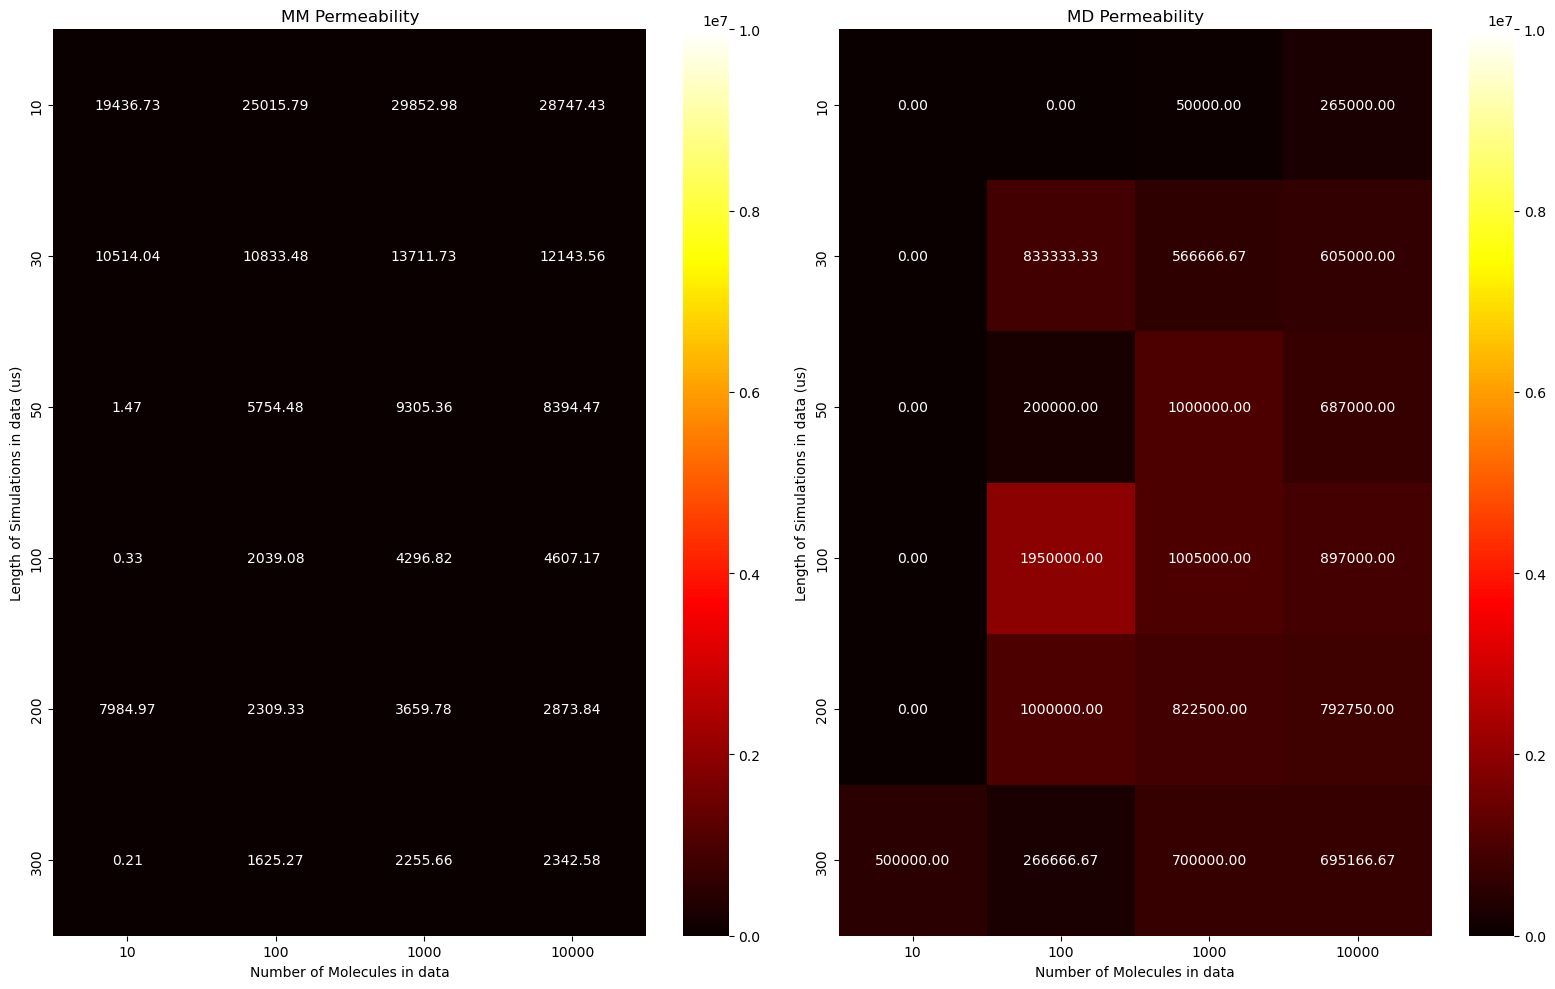

In [10]:
# visualize permiabilities

with open(f"data/permiabilities/mm-permiabilities-fast.pickle", "rb") as f:
    mm_perms = pickle.load(f)
with open(f"data/permiabilities/md-permiabilities.pickle", "rb") as f:
    md_perms = pickle.load(f)
    
# Setting up the figure
plt.figure(figsize=(16, 10))

# First heatmap - MM Permeability
plt.subplot(1, 2, 1)
ax1 = sns.heatmap(mm_perms, cmap='hot', annot=True, fmt=".2f", 
                 xticklabels=amounts, yticklabels=lengths, vmin=0, vmax=1e7)
plt.xlabel('Number of Molecules in data')
plt.ylabel('Length of Simulations in data (us)')
plt.title('MM Permeability')

# Second heatmap - MD Permeability
plt.subplot(1, 2, 2)
ax2 = sns.heatmap(md_perms, cmap='hot', annot=True, fmt=".2f",
                 xticklabels=amounts, yticklabels=lengths, vmin=0, vmax=1e7)
plt.xlabel('Number of Molecules in data')
plt.ylabel('Length of Simulations in data (us)')
plt.title('MD Permeability')

plt.tight_layout()
plt.show()